In [2]:
import sys
import logging
import pandas as pd
import numpy as np

In [3]:
# 1. Initialize module-level logger (never use root logger directly)
logger = logging.getLogger(__name__)


def setup_logging(log_filename: str = "pipeline.log") -> None:
    """
    Configures logging handlers and formatters to write to both
    the console and a log file.
    """
    logger.setLevel(logging.DEBUG)  # Capture all log levels at module level

    # Define standard log layout: Timestamp - Level - Module - Message
    formatter = logging.Formatter(
        "%(asctime)s - %(levelname)s - %(name)s - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Console Handler (INFO level and above)
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)

    # File Handler (INFO level and above, mode='w' clears previous run logs)
    file_handler = logging.FileHandler(log_filename, mode='w')
    file_handler.setLevel(logging.INFO)
    file_handler.setFormatter(formatter)

    # Prevent duplicate handlers if script is re-run
    if logger.hasHandlers():
        logger.handlers.clear()

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)


def load_data(filepath: str) -> pd.DataFrame:
    """Loads the raw traffic dataset with try/except exception handling."""
    logger.info("Attempting to load dataset from file: '%s'", filepath)
    try:
        df = pd.read_csv(filepath)
        num_rows, num_cols = df.shape
        logger.info(
            "Successfully loaded raw dataset '%s' with %d rows and %d columns.",
            filepath, num_rows, num_cols
        )
        return df
    except Exception as e:
        logger.error(
            "Failed to load raw dataset from path '%s': %s",
            filepath, e, exc_info=True
        )
        sys.exit(1)


def validate_schema(df: pd.DataFrame, expected_columns: list) -> bool:
    """Validates that all required columns are present in the dataset."""
    logger.info("Validating dataset schema against expected columns...")
    missing_columns = [col for col in expected_columns if col not in df.columns]

    if missing_columns:
        logger.error(
            "Schema validation failed! Missing required column(s): %s",
            missing_columns
        )
        sys.exit(1)

    logger.info("Schema validation passed. All %d expected columns are present.", len(expected_columns))
    return True


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Executes sequential data-cleaning steps, logging each action separately.
    """
    df = df.copy()

    # Step 1: Standardise categorical string values
    logger.info("Cleaning Step 1: Standardising categorical text fields...")
    if 'weather_main' in df.columns:
        df['weather_main'] = df['weather_main'].astype(str).str.strip().str.title()
        logger.info("Categorical column 'weather_main' whitespace stripped and title-cased.")

    # Step 2: Parse and validate DateTime
    logger.info("Cleaning Step 2: Parsing and validating 'date_time' column...")
    try:
        df['date_time'] = pd.to_datetime(df['date_time'])
        logger.info("Successfully converted 'date_time' to datetime format.")
    except Exception as e:
        logger.error("Failed to parse 'date_time' column: %s", e, exc_info=True)
        sys.exit(1)

    # Step 3: Remove Duplicate Rows
    logger.info("Cleaning Step 3: Checking for duplicate rows...")
    initial_rows = len(df)
    df = df.drop_duplicates()
    duplicates_removed = initial_rows - len(df)

    if duplicates_removed > 0:
        logger.warning(
            "Dropped %d duplicate rows from dataset. Remaining row count: %d.",
            duplicates_removed, len(df)
        )
    else:
        logger.info("No duplicate rows detected in dataset.")

    # Extract temporary month feature for monthly median imputation
    df['month'] = df['date_time'].dt.month

    # Step 4: Handle Temperature Outliers (0 Kelvin physics anomaly)
    logger.info("Cleaning Step 4: Scanning for physically impossible temperature readings...")
    invalid_temp_mask = df['temp'] <= 0
    invalid_temp_count = invalid_temp_mask.sum()

    if invalid_temp_count > 0:
        logger.warning(
            "Found %d rows with invalid temperature readings (<= 0 K). Imputing values using monthly median.",
            invalid_temp_count
        )
        df.loc[invalid_temp_mask, 'temp'] = np.nan

        # Group-by-group monthly median imputation using explicit loop
        unique_months = df['month'].unique()
        for m in unique_months:
            month_mask = df['month'] == m
            monthly_median = df.loc[month_mask, 'temp'].median()
            df.loc[month_mask & df['temp'].isna(), 'temp'] = monthly_median
            logger.info("Imputed missing temperatures for Month %d using median value: %.2f K.", m, monthly_median)

    # Step 5: Handle Extreme Rainfall Outliers (e.g., > 9,000mm anomaly)
    logger.info("Cleaning Step 5: Scanning for severe rainfall outliers...")
    rain_outlier_mask = df['rain_1h'] > 1000
    rain_outlier_count = rain_outlier_mask.sum()

    if rain_outlier_count > 0:
        logger.warning(
            "Found %d extreme rainfall outlier rows (> 1000mm). Imputing values using monthly median.",
            rain_outlier_count
        )
        df.loc[rain_outlier_mask, 'rain_1h'] = np.nan

        for m in df['month'].unique():
            month_mask = df['month'] == m
            monthly_median = df.loc[month_mask, 'rain_1h'].median()
            df.loc[month_mask & df['rain_1h'].isna(), 'rain_1h'] = monthly_median
            logger.info("Imputed rainfall outliers for Month %d using median value: %.2f mm.", m, monthly_median)

    # Clean up temporary helper column
    df = df.drop(columns=['month'])

    logger.info("Data cleaning workflow complete. Final processed shape: %d rows, %d columns.", df.shape[0], df.shape[1])
    return df


if __name__ == "__main__":
    # Configure logging handlers
    setup_logging("pipeline.log")

    logger.info("==========================================")
    logger.info("Starting Metro Traffic Data Pipeline execution")
    logger.info("==========================================")

    # Configuration setup
    csv_file_path = "Metro_Interstate_Traffic_Volume.csv"
    required_schema = [
        "holiday", "temp", "rain_1h", "snow_1h",
        "clouds_all", "weather_main", "weather_description",
        "date_time", "traffic_volume"
    ]

    # Execution workflow
    raw_df = load_data(csv_file_path)
    validate_schema(raw_df, required_schema)
    cleaned_df = clean_data(raw_df)

    # Export cleaned dataset
    output_path = "cleaned_traffic_data.csv"
    cleaned_df.to_csv(output_path, index=False)
    logger.info("Successfully exported cleaned pipeline data to '%s'. Execution finished.", output_path)

2026-09-27 02:13:45 - INFO - __main__ - ==========================================
2026-09-27 02:13:45 - INFO - __main__ - Starting Metro Traffic Data Pipeline execution
2026-09-27 02:13:45 - INFO - __main__ - ==========================================
2026-09-27 02:13:45 - INFO - __main__ - Attempting to load dataset from file: 'Metro_Interstate_Traffic_Volume.csv'
2026-09-27 02:13:45 - INFO - __main__ - Successfully loaded raw dataset 'Metro_Interstate_Traffic_Volume.csv' with 48204 rows and 9 columns.
2026-09-27 02:13:45 - INFO - __main__ - Validating dataset schema against expected columns...
2026-09-27 02:13:45 - INFO - __main__ - Schema validation passed. All 9 expected columns are present.
2026-09-27 02:13:45 - INFO - __main__ - Cleaning Step 1: Standardising categorical text fields...
2026-09-27 02:13:45 - INFO - __main__ - Categorical column 'weather_main' whitespace stripped and title-cased.
2026-09-27 02:13:45 - INFO - __main__ - Cleaning Step 2: Parsing and validating 'date

In [4]:
import pandas as pd
import numpy as np
import logging
import sys

# 1. Initialize logger for this module
logger = logging.getLogger(__name__)

# 2. Configure logging to print to stdout (Jupyter output cell)
handler = logging.StreamHandler(sys.stdout)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
handler.setFormatter(formatter)

# Clear existing handlers to prevent duplicate output when re-running cells
if logger.hasHandlers():
    logger.handlers.clear()

logger.addHandler(handler)
logger.setLevel(logging.DEBUG)  # Set to DEBUG to capture intermediate threshold calculations

logger.info("Logging configured successfully for Jupyter Notebook.")

02:13:46 - INFO - Logging configured successfully for Jupyter Notebook.


In [5]:
# Load the cleaned dataset output from Task 1
df = pd.read_csv("cleaned_traffic_data.csv")
df['date_time'] = pd.to_datetime(df['date_time'])

# Log shape BEFORE feature engineering
logger.info(f"Dataset shape BEFORE feature engineering: {df.shape[0]} rows, {df.shape[1]} columns")

02:13:46 - INFO - Dataset shape BEFORE feature engineering: 48187 rows, 9 columns


In [6]:
# 1. Standard time extractions
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 2. Cyclical encoding for Hour (24-hour cycle)
# Formula: sin(2 * pi * hour / 24) and cos(2 * pi * hour / 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

# 3. Cyclical encoding for Day of Week (7-day cycle)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

logger.info("Time features engineered: hour, day_of_week, is_weekend, and cyclical sin/cos encodings.")

02:13:46 - INFO - Time features engineered: hour, day_of_week, is_weekend, and cyclical sin/cos encodings.


In [7]:
# 1. Derive domain-specific weather flags
df['is_freezing'] = (df['temp'] < 273.15).astype(int)  # 273.15 Kelvin = 0 Celsius
df['is_raining'] = (df['rain_1h'] > 0).astype(int)

# 2. One-Hot Encode main weather categories
weather_dummies = pd.get_dummies(df['weather_main'], prefix='weather', dtype=int)
df = pd.concat([df, weather_dummies], axis=1)

logger.info(f"Weather features engineered: derived indicators and {weather_dummies.shape[1]} weather category encodings.")

02:13:46 - INFO - Weather features engineered: derived indicators and 11 weather category encodings.


In [8]:
# Min-Max Scaling function: (x - min) / (max - min)
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Create scaled features for temperature and cloud coverage
df['temp_scaled'] = min_max_scale(df['temp'])
df['clouds_scaled'] = min_max_scale(df['clouds_all'])

logger.info("Numerical features scaled using Min-Max scaling: temp_scaled, clouds_scaled.")

02:13:46 - INFO - Numerical features scaled using Min-Max scaling: temp_scaled, clouds_scaled.


In [9]:
# 1. Calculate quartile thresholds
q1, q2, q3 = df['traffic_volume'].quantile([0.25, 0.50, 0.75]).values

# Log intermediate threshold values at DEBUG level
logger.debug(f"Intermediate Calculation - Traffic Quartile Thresholds: Q1 (25%) = {q1:.1f}, Q2 (50%) = {q2:.1f}, Q3 (75%) = {q3:.1f}")

# 2. Define categorization function based on quartiles
def categorize_congestion(val):
    if val <= q1:
        return 'Low'
    elif val <= q2:
        return 'Medium'
    elif val <= q3:
        return 'High'
    else:
        return 'Severe'

# Apply categorization
df['congestion_category'] = df['traffic_volume'].apply(categorize_congestion)

logger.info("Traffic target variable 'congestion_category' created using quartile distribution.")

02:13:46 - DEBUG - Intermediate Calculation - Traffic Quartile Thresholds: Q1 (25%) = 1192.5, Q2 (50%) = 3379.0, Q3 (75%) = 4933.0
02:13:46 - INFO - Traffic target variable 'congestion_category' created using quartile distribution.


In [10]:
# Log shape AFTER feature engineering
logger.info(f"Dataset shape AFTER feature engineering: {df.shape[0]} rows, {df.shape[1]} columns")

# Export feature-engineered dataset for Part 3 (Machine Learning)
output_path = "engineered_traffic_data.csv"
df.to_csv(output_path, index=False)
logger.info(f"Engineered dataset successfully saved to '{output_path}'.")

# Display sample output table
df[['date_time', 'traffic_volume', 'congestion_category', 'hour_sin', 'temp_scaled', 'is_weekend']].head()

02:13:46 - INFO - Dataset shape AFTER feature engineering: 48187 rows, 32 columns
02:13:47 - INFO - Engineered dataset successfully saved to 'engineered_traffic_data.csv'.


,date_time,traffic_volume,congestion_category,hour_sin,temp_scaled,is_weekend
0,2012-10-02 09:00:00,5545,Severe,7.071068e-01,0.673215,0
1,2012-10-02 10:00:00,4516,High,5.000000e-01,0.689412,0
2,2012-10-02 11:00:00,4767,High,2.588190e-01,0.692711,0
3,2012-10-02 12:00:00,5026,Severe,1.224647e-16,0.700960,0
4,2012-10-02 13:00:00,4918,High,-2.588190e-01,0.716107,0


In [12]:
import os
import sys
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create directory to save output figures
os.makedirs('figures', exist_ok=True)

# 2. Initialize and configure logger
logger = logging.getLogger(__name__)
handler = logging.StreamHandler(sys.stdout)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
handler.setFormatter(formatter)

if logger.hasHandlers():
    logger.handlers.clear()

logger.addHandler(handler)
logger.setLevel(logging.INFO)

logger.info("Task 3 setup complete. Output directory 'figures/' created.")

02:18:12 - INFO - Task 3 setup complete. Output directory 'figures/' created.


In [13]:
df = pd.read_csv("engineered_traffic_data.csv")
df['date_time'] = pd.to_datetime(df['date_time'])

logger.info(f"Loaded dataset with {len(df)} rows and {len(df.columns)} columns for visualization.")

02:20:07 - INFO - Loaded dataset with 48187 rows and 32 columns for visualization.


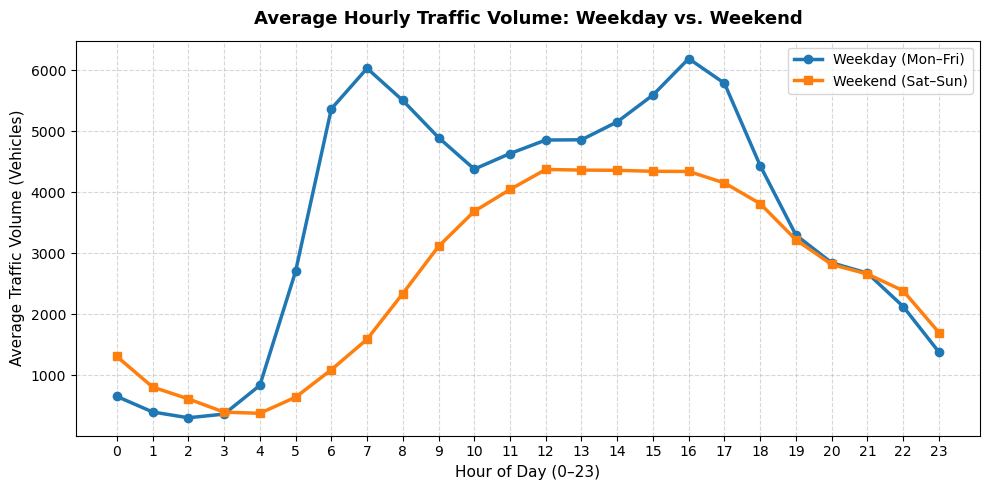

02:24:34 - INFO - Figure 1 successfully saved to path: 'figures/hourly_traffic_weekday_vs_weekend.png'


In [14]:
plt.figure(figsize=(10, 5))

# Group traffic volume by hour and weekend flag
hourly_traffic = df.groupby(['hour', 'is_weekend'])['traffic_volume'].mean().unstack()

plt.plot(hourly_traffic.index, hourly_traffic[0], label='Weekday (Mon–Fri)', color='#1f77b4', linewidth=2.5, marker='o')
plt.plot(hourly_traffic.index, hourly_traffic[1], label='Weekend (Sat–Sun)', color='#ff7f0e', linewidth=2.5, marker='s')

plt.title('Average Hourly Traffic Volume: Weekday vs. Weekend', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Hour of Day (0–23)', fontsize=11)
plt.ylabel('Average Traffic Volume (Vehicles)', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

# Save figure and log path (Mandatory requirement)
fig1_path = 'figures/hourly_traffic_weekday_vs_weekend.png'
plt.savefig(fig1_path, dpi=300)
plt.show()

logger.info(f"Figure 1 successfully saved to path: '{fig1_path}'")

C:\Users\chewd\AppData\Local\Temp\ipykernel_6684\3647788657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


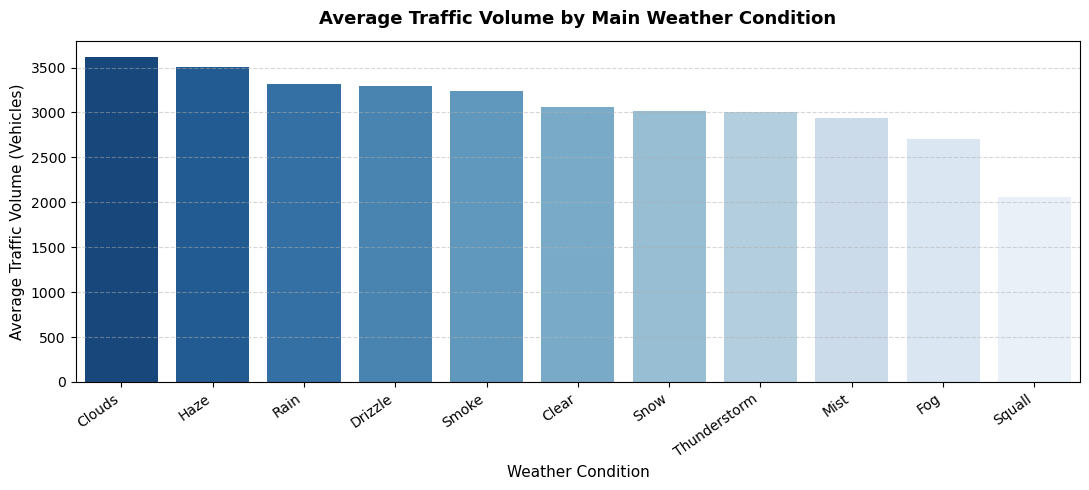

02:24:59 - INFO - Figure 2 successfully saved to path: 'figures/traffic_by_weather_condition.png'


In [15]:
plt.figure(figsize=(11, 5))

# Order weather categories by mean traffic volume
weather_order = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='weather_main',
    y='traffic_volume',
    order=weather_order,
    palette='Blues_r',
    errorbar=None
)

plt.title('Average Traffic Volume by Main Weather Condition', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Weather Condition', fontsize=11)
plt.ylabel('Average Traffic Volume (Vehicles)', fontsize=11)
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure and log path (Mandatory requirement)
fig2_path = 'figures/traffic_by_weather_condition.png'
plt.savefig(fig2_path, dpi=300)
plt.show()

logger.info(f"Figure 2 successfully saved to path: '{fig2_path}'")

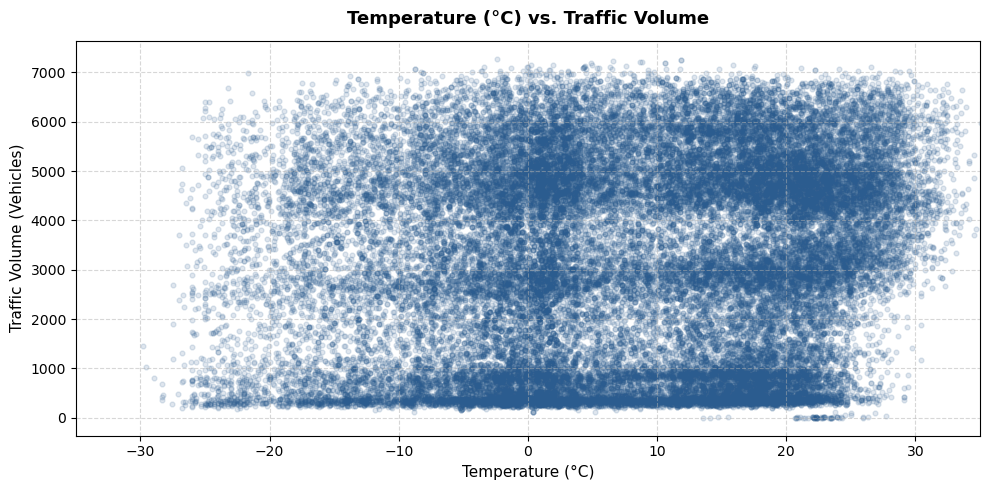

02:25:21 - INFO - Figure 3 successfully saved to path: 'figures/temperature_vs_traffic.png'


In [16]:
plt.figure(figsize=(10, 5))

# Convert Kelvin to Celsius for intuitive display
temp_celsius = df['temp'] - 273.15

plt.scatter(temp_celsius, df['traffic_volume'], alpha=0.15, color='#2b5c8f', s=12)

plt.title('Temperature (°C) vs. Traffic Volume', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Temperature (°C)', fontsize=11)
plt.ylabel('Traffic Volume (Vehicles)', fontsize=11)
plt.xlim(-35, 35)  # Focus range excluding 0 Kelvin anomalies
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure and log path (Mandatory requirement)
fig3_path = 'figures/temperature_vs_traffic.png'
plt.savefig(fig3_path, dpi=300)
plt.show()

logger.info(f"Figure 3 successfully saved to path: '{fig3_path}'")

In [17]:
import pandas as pd
import logging
import sys

# Initialize logger for Task 4
logger = logging.getLogger(__name__)

class TrafficAnalyticsApp:
    def __init__(self, data_path: str = "engineered_traffic_data.csv"):
        try:
            self.df = pd.read_csv(data_path)
            self.df['date_time'] = pd.to_datetime(self.df['date_time'])
            logger.info(f"App initialized successfully with dataset from '{data_path}'.")
        except Exception as e:
            logger.error(f"Failed to load dataset for application: {e}", exc_info=True)
            raise

    def query_datetime(self, datetime_str: str):
        """Command 1: Query traffic and weather conditions for a specific timestamp."""
        logger.info(f"Command Invoked: 'query_datetime' | Arguments: datetime_str='{datetime_str}'")
        
        # Input validation
        try:
            target_dt = pd.to_datetime(datetime_str)
        except Exception:
            logger.error(f"Invalid input argument: '{datetime_str}' could not be parsed as a valid datetime format (e.g., 'YYYY-MM-DD HH:MM:SS').")
            print(f"[ERROR] Invalid date format: '{datetime_str}'. Please use 'YYYY-MM-DD HH:MM:SS'.")
            return

        result = self.df[self.df['date_time'] == target_dt]

        if result.empty:
            logger.warning(f"No traffic records found matching timestamp: '{target_dt}'.")
            print(f"\n--- QUERY RESULT ---")
            print(f"No records found for: {target_dt}")
        else:
            row = result.iloc[0]
            # print() used ONLY for displaying requested query results to the user
            print(f"\n--- QUERY RESULT: {target_dt} ---")
            print(f"Traffic Volume     : {row['traffic_volume']} vehicles")
            print(f"Congestion Category: {row['congestion_category']}")
            print(f"Temperature        : {row['temp'] - 273.15:.1f} °C")
            print(f"Weather Condition  : {row['weather_main']} ({row['weather_description']})")

    def query_peak_hours(self, day_type: str = "weekday", top_n: int = 3):
        """Command 2: Identify top N peak congestion hours for weekdays or weekends."""
        logger.info(f"Command Invoked: 'query_peak_hours' | Arguments: day_type='{day_type}', top_n={top_n}")
        
        day_type_clean = str(day_type).strip().lower()
        if day_type_clean not in ['weekday', 'weekend']:
            logger.error(f"Invalid day_type argument: '{day_type}'. Expected 'weekday' or 'weekend'.")
            print(f"[ERROR] Invalid day_type: '{day_type}'. Choose either 'weekday' or 'weekend'.")
            return

        is_wknd = 1 if day_type_clean == 'weekend' else 0
        filtered = self.df[self.df['is_weekend'] == is_wknd]
        peak = filtered.groupby('hour')['traffic_volume'].mean().nlargest(top_n).reset_index()

        print(f"\n--- TOP {top_n} PEAK TRAFFIC HOURS ({day_type_clean.upper()}) ---")
        for i, r in peak.iterrows():
            print(f"Rank {i+1}: Hour {int(r['hour']):02d}:00 -> Avg Volume: {r['traffic_volume']:.0f} vehicles")

    def recommend_travel_window(self, target_hour_start: int, target_hour_end: int):
        """Command 3: Analyze traffic conditions within a time window and give advice."""
        logger.info(f"Command Invoked: 'recommend_travel_window' | Arguments: start={target_hour_start}, end={target_hour_end}")
        
        if not (0 <= target_hour_start <= 23 and 0 <= target_hour_end <= 23) or target_hour_start >= target_hour_end:
            logger.error(f"Invalid hour range arguments: start={target_hour_start}, end={target_hour_end}.")
            print("[ERROR] Invalid hour range. Hours must be between 0 and 23, and start hour must be less than end hour.")
            return

        subset = self.df[(self.df['hour'] >= target_hour_start) & (self.df['hour'] <= target_hour_end)]
        avg_vol = subset['traffic_volume'].mean()
        min_hour = subset.groupby('hour')['traffic_volume'].mean().idxmin()

        print(f"\n--- TRAVEL RECOMMENDATION WINDOW ({target_hour_start:02d}:00 to {target_hour_end:02d}:00) ---")
        print(f"Average Volume in Window : {avg_vol:.0f} vehicles")
        print(f"Optimal Time to Travel   : Depart around {min_hour:02d}:00 (Lowest historical average volume)")

# Initialize global application instance
app = TrafficAnalyticsApp()

02:29:18 - INFO - App initialized successfully with dataset from 'engineered_traffic_data.csv'.


In [18]:
# Query a specific date and time
app.query_datetime("2017-09-15 17:00:00")

02:29:28 - INFO - Command Invoked: 'query_datetime' | Arguments: datetime_str='2017-09-15 17:00:00'

--- QUERY RESULT: 2017-09-15 17:00:00 ---
Traffic Volume     : 5700 vehicles
Congestion Category: Severe
Temperature        : 27.0 °C
Weather Condition  : Clear (sky is clear)


In [19]:
# Compare top peak hours for weekdays
app.query_peak_hours(day_type="weekday", top_n=3)

# Compare top peak hours for weekends
app.query_peak_hours(day_type="weekend", top_n=3)

02:29:46 - INFO - Command Invoked: 'query_peak_hours' | Arguments: day_type='weekday', top_n=3

--- TOP 3 PEAK TRAFFIC HOURS (WEEKDAY) ---
Rank 1: Hour 16:00 -> Avg Volume: 6189 vehicles
Rank 2: Hour 07:00 -> Avg Volume: 6030 vehicles
Rank 3: Hour 17:00 -> Avg Volume: 5785 vehicles
02:29:46 - INFO - Command Invoked: 'query_peak_hours' | Arguments: day_type='weekend', top_n=3

--- TOP 3 PEAK TRAFFIC HOURS (WEEKEND) ---
Rank 1: Hour 12:00 -> Avg Volume: 4372 vehicles
Rank 2: Hour 13:00 -> Avg Volume: 4362 vehicles
Rank 3: Hour 14:00 -> Avg Volume: 4359 vehicles


In [20]:
# Request recommendation for morning travel window (07:00 to 11:00)
app.recommend_travel_window(target_hour_start=7, target_hour_end=11)

02:29:52 - INFO - Command Invoked: 'recommend_travel_window' | Arguments: start=7, end=11

--- TRAVEL RECOMMENDATION WINDOW (07:00 to 11:00) ---
Average Volume in Window : 4473 vehicles
Optimal Time to Travel   : Depart around 10:00 (Lowest historical average volume)


In [21]:
print("--- TESTING ERROR HANDLING 1: MALFORMED DATE ---")
app.query_datetime("2017-99-99 25:00:00")

print("\n--- TESTING ERROR HANDLING 2: INVALID HOUR RANGE ---")
app.recommend_travel_window(target_hour_start=18, target_hour_end=8)

--- TESTING ERROR HANDLING 1: MALFORMED DATE ---
02:30:00 - INFO - Command Invoked: 'query_datetime' | Arguments: datetime_str='2017-99-99 25:00:00'
02:30:00 - ERROR - Invalid input argument: '2017-99-99 25:00:00' could not be parsed as a valid datetime format (e.g., 'YYYY-MM-DD HH:MM:SS').
[ERROR] Invalid date format: '2017-99-99 25:00:00'. Please use 'YYYY-MM-DD HH:MM:SS'.

--- TESTING ERROR HANDLING 2: INVALID HOUR RANGE ---
02:30:00 - INFO - Command Invoked: 'recommend_travel_window' | Arguments: start=18, end=8
02:30:00 - ERROR - Invalid hour range arguments: start=18, end=8.
[ERROR] Invalid hour range. Hours must be between 0 and 23, and start hour must be less than end hour.
